# End-to-End ML Pipeline: Tesla Sales / Deliveries and Price Data

This lightweight notebook covers preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and simple time series forecasting. It is intentionally output-free so it renders quickly on GitHub.

**Dataset expected:** `tesla_deliveries_dataset_2015_2025.csv` placed either in this folder or one level above it.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 80)

## 1. Load Data

In [2]:
candidate_paths = [
    Path('tesla_deliveries_dataset_2015_2025.csv'),
    Path('..') / 'tesla_deliveries_dataset_2015_2025.csv',
    Path(r'C:/Users/khush/OneDrive/Desktop/tesla_deliveries_dataset_2015_2025.csv'),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Place tesla_deliveries_dataset_2015_2025.csv in this folder or one level above it.')

raw_df = pd.read_csv(data_path)
raw_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df = raw_df.copy()
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r'[^0-9a-zA-Z]+', '_', regex=True)
    .str.strip('_')
)

print(f'Shape: {df.shape}')
display(df.head())
display(df.info())

Shape: (2640, 12)


,year,month,region,model,estimated_deliveries,production_units,avg_price_usd,battery_capacity_kwh,range_km,co2_saved_tons,source_type,charging_stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  2640 non-null   int64  
 1   month                 2640 non-null   int64  
 2   region                2640 non-null   object 
 3   model                 2640 non-null   object 
 4   estimated_deliveries  2640 non-null   int64  
 5   production_units      2640 non-null   int64  
 6   avg_price_usd         2640 non-null   float64
 7   battery_capacity_kwh  2640 non-null   int64  
 8   range_km              2640 non-null   int64  
 9   co2_saved_tons        2640 non-null   float64
 10  source_type           2640 non-null   object 
 11  charging_stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


None

## 2. Preprocessing

In [4]:
date_candidates = [col for col in df.columns if any(key in col for key in ['date', 'quarter', 'month', 'year'])]
target_candidates = [col for col in df.columns if any(key in col for key in ['deliver', 'sales', 'sold', 'units', 'volume'])]
price_candidates = [col for col in df.columns if any(key in col for key in ['price', 'revenue', 'asp', 'amount'])]

date_col = date_candidates[0] if date_candidates else None
target_col = target_candidates[0] if target_candidates else None
price_col = price_candidates[0] if price_candidates else None

print('Detected date column:', date_col)
print('Detected target column:', target_col)
print('Detected price column:', price_col)

if target_col is None:
    raise ValueError('No sales/deliveries target column was detected. Rename the target column to include deliveries, sales, units, or volume.')

Detected date column: year
Detected target column: estimated_deliveries
Detected price column: avg_price_usd


In [5]:
for col in df.columns:
    if col != date_col and df[col].dtype == 'object':
        converted = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('$', '', regex=False), errors='coerce')
        if converted.notna().mean() >= 0.7:
            df[col] = converted

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
else:
    df['date'] = pd.date_range('2015-01-01', periods=len(df), freq='Q')
    date_col = 'date'

df = df.drop_duplicates().sort_values(date_col).reset_index(drop=True)
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[date_col, target_col])

missing_summary = df.isna().mean().sort_values(ascending=False).to_frame('missing_rate')
display(missing_summary.head(10))
display(df.describe(include='all').T.head(15))

,missing_rate
year,0.0
month,0.0
region,0.0
model,0.0
estimated_deliveries,0.0
production_units,0.0
avg_price_usd,0.0
battery_capacity_kwh,0.0
range_km,0.0
co2_saved_tons,0.0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
year,2640,NaN,NaN,NaN,1970-01-01 00:00:00.000002020,1970-01-01 00:00:00.000002015,1970-01-01 00:00:00.000002017,1970-01-01 00:00:00.000002020,1970-01-01 00:00:00.000002023,1970-01-01 00:00:00.000002025,NaN
month,2640.0,NaN,NaN,NaN,6.5,1.0,3.75,6.5,9.25,12.0,3.452707
region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,2640,5,Model X,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estimated_deliveries,2640.0,NaN,NaN,NaN,9922.199621,48.0,7292.0,9857.0,12510.25,25704.0,3935.950093
production_units,2640.0,NaN,NaN,NaN,10655.847348,50.0,7828.25,10546.5,13469.0,28939.0,4260.600858
avg_price_usd,2640.0,NaN,NaN,NaN,84907.34033,50003.7,67726.365,85058.51,102373.0425,119965.36,20123.258036
battery_capacity_kwh,2640.0,NaN,NaN,NaN,87.05947,60.0,75.0,82.0,100.0,120.0,20.836265
range_km,2640.0,NaN,NaN,NaN,500.257576,330.0,418.0,470.0,586.25,719.0,120.868549
co2_saved_tons,2640.0,NaN,NaN,NaN,744.076989,3.07,499.62,699.515,943.765,2548.55,353.221224


## 3. Exploratory Data Analysis

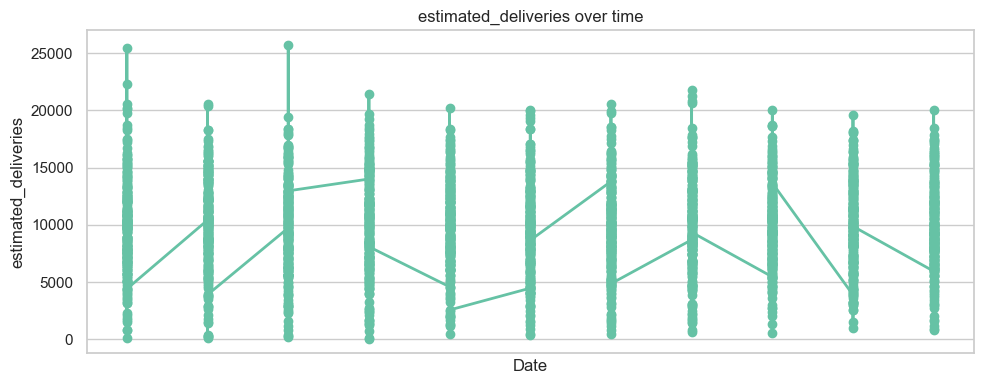

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df[date_col], df[target_col], marker='o', linewidth=2)
ax.set_title(f'{target_col} over time')
ax.set_xlabel('Date')
ax.set_ylabel(target_col)
plt.xticks(rotation=30)
plt.tight_layout()

,estimated_deliveries
estimated_deliveries,1.000000
production_units,0.994234
co2_saved_tons,0.836814
month,0.030877
charging_stations,0.000753
range_km,-0.006606
battery_capacity_kwh,-0.007765
avg_price_usd,-0.027546


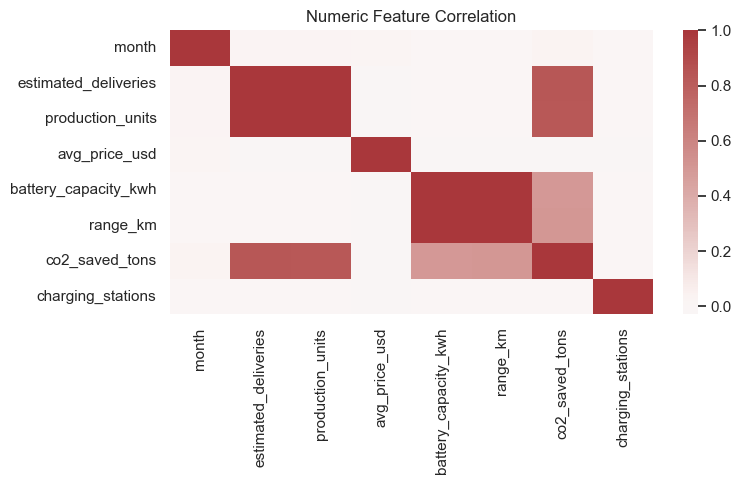

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if numeric_cols:
    display(df[numeric_cols].corr()[[target_col]].sort_values(target_col, ascending=False))
    plt.figure(figsize=(8, 5))
    sns.heatmap(df[numeric_cols].corr(), cmap='vlag', center=0, annot=False)
    plt.title('Numeric Feature Correlation')
    plt.tight_layout()

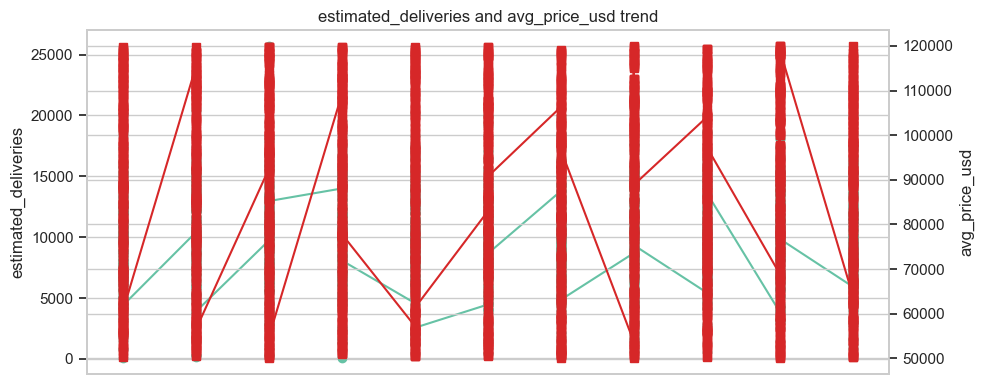

In [8]:
if price_col and price_col in df.columns:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df[date_col], df[target_col], marker='o', label=target_col)
    ax1.set_ylabel(target_col)
    ax2 = ax1.twinx()
    ax2.plot(df[date_col], df[price_col], color='tab:red', marker='s', label=price_col)
    ax2.set_ylabel(price_col)
    plt.title(f'{target_col} and {price_col} trend')
    plt.tight_layout()

## 4. Feature Engineering

In [16]:
model_df = df.copy().sort_values(date_col).reset_index(drop=True)

# Ensure date features work even if the source date column was read as text.
date_series = pd.to_datetime(model_df[date_col], errors='coerce')
if isinstance(date_series, pd.DataFrame):
    date_series = date_series.iloc[:, 0]
model_df[date_col] = date_series
model_df[target_col] = pd.to_numeric(model_df[target_col], errors='coerce')
model_df = model_df.dropna(subset=[date_col, target_col]).reset_index(drop=True)

parsed_dates = pd.DatetimeIndex(model_df[date_col])
model_df['year'] = parsed_dates.year
model_df['month'] = parsed_dates.month
model_df['quarter'] = ((model_df['month'] - 1) // 3) + 1
model_df['time_index'] = np.arange(len(model_df))

engineered_cols = ['year', 'quarter', 'month', 'time_index']

# Create only the lag/rolling features that the available history can support.
valid_lags = [lag for lag in [1, 2, 4] if lag < len(model_df)]
for lag in valid_lags:
    col_name = f'{target_col}_lag_{lag}'
    model_df[col_name] = model_df[target_col].shift(lag)
    engineered_cols.append(col_name)

valid_windows = [window for window in [2, 4] if window < len(model_df)]
for window in valid_windows:
    col_name = f'{target_col}_rolling_mean_{window}'
    model_df[col_name] = model_df[target_col].shift(1).rolling(window).mean()
    engineered_cols.append(col_name)

pct_col = f'{target_col}_pct_change_1'
model_df[pct_col] = model_df[target_col].pct_change().replace([np.inf, -np.inf], np.nan)
engineered_cols.append(pct_col)

# Drop rows only for required modeling fields, not every original column.
model_df = model_df.dropna(subset=[target_col, date_col] + engineered_cols).reset_index(drop=True)

if model_df.empty:
    raise ValueError('Feature engineering removed all rows. Use more time periods or reduce lag/rolling features.')

display(model_df.head())
print('Modeling shape:', model_df.shape)

,year,month,region,model,estimated_deliveries,production_units,avg_price_usd,battery_capacity_kwh,range_km,co2_saved_tons,source_type,charging_stations,quarter,time_index,estimated_deliveries_lag_1,estimated_deliveries_lag_2,estimated_deliveries_lag_4,estimated_deliveries_rolling_mean_2,estimated_deliveries_rolling_mean_4,estimated_deliveries_pct_change_1
0,1970,1,Middle East,Model S,6812,6939,101160.72,120,716,731.61,Estimated (Region),5174,1,4,7292.0,7602.0,8458.0,7447.0,8411.25,-0.065826
1,1970,1,Asia,Model 3,8761,8999,90812.91,75,428,562.46,Estimated (Region),13712,1,5,6812.0,7292.0,10293.0,7052.0,7999.75,0.286113
2,1970,1,Europe,Cybertruck,5325,5514,100975.14,82,466,372.22,Interpolated (Month),10587,1,6,8761.0,6812.0,7602.0,7786.5,7616.75,-0.392193
3,1970,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,1,7,5325.0,8761.0,7292.0,7043.0,7047.50,1.126761
4,1970,1,North America,Model X,7705,7747,83044.69,82,474,547.83,Official (Quarter),3788,1,8,11325.0,5325.0,6812.0,8325.0,8055.75,-0.319647


Modeling shape: (2636, 20)


## 5. Regression Modeling

In [17]:
drop_cols = [target_col, date_col]
X = model_df.drop(columns=[col for col in drop_cols if col in model_df.columns])
y = model_df[target_col]

split_idx = max(1, int(len(model_df) * 0.8))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
    ],
    remainder='drop'
)

def evaluate_model(name, estimator):
    estimator.fit(X_train, y_train)
    preds = estimator.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {
        'model': name,
        'mae': mean_absolute_error(y_test, preds),
        'rmse': rmse,
        'r2': r2_score(y_test, preds) if len(y_test) > 1 else np.nan,
    }, preds

models = {
    'Ridge Regression': Pipeline([('preprocess', preprocessor), ('model', Ridge())]),
    'Random Forest': Pipeline([('preprocess', preprocessor), ('model', RandomForestRegressor(random_state=42, n_estimators=150))]),
}

results, predictions = [], {}
for name, estimator in models.items():
    metrics, preds = evaluate_model(name, estimator)
    results.append(metrics)
    predictions[name] = preds

results_df = pd.DataFrame(results).sort_values('rmse')
display(results_df)

,model,mae,rmse,r2
0,Ridge Regression,321.407992,393.308398,0.988946
1,Random Forest,328.002424,409.745703,0.988002


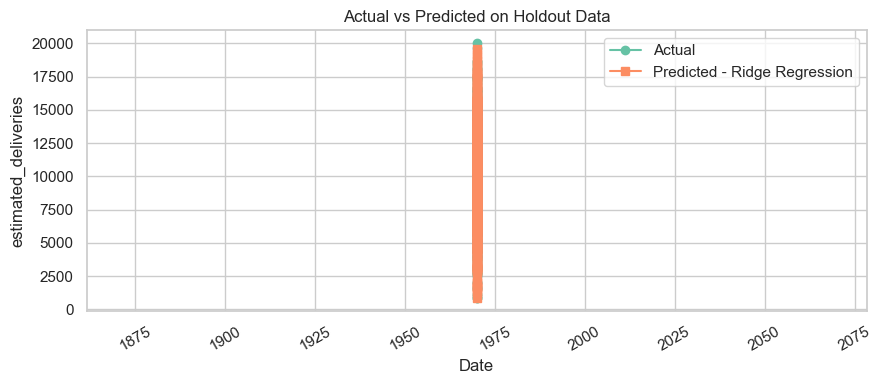

In [18]:
best_name = results_df.iloc[0]['model']
plt.figure(figsize=(9, 4))
plt.plot(model_df.loc[y_test.index, date_col], y_test.values, marker='o', label='Actual')
plt.plot(model_df.loc[y_test.index, date_col], predictions[best_name], marker='s', label=f'Predicted - {best_name}')
plt.title('Actual vs Predicted on Holdout Data')
plt.xlabel('Date')
plt.ylabel(target_col)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()

## 6. Hyperparameter Tuning

In [19]:
n_splits = min(3, max(2, len(X_train) // 5))
tscv = TimeSeriesSplit(n_splits=n_splits)

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, None],
    'model__min_samples_leaf': [1, 2],
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
grid.fit(X_train, y_train)

tuned_preds = grid.predict(X_test)
tuned_metrics = {
    'best_params': grid.best_params_,
    'mae': mean_absolute_error(y_test, tuned_preds),
    'rmse': np.sqrt(mean_squared_error(y_test, tuned_preds)),
    'r2': r2_score(y_test, tuned_preds) if len(y_test) > 1 else np.nan,
}
tuned_metrics

{'best_params': {'model__max_depth': None,
  'model__min_samples_leaf': 1,
  'model__n_estimators': 200},
 'mae': 329.55558712121206,
 'rmse': np.float64(410.8086248427246),
 'r2': 0.9879401634741767}

## 7. Time Series Forecasting

In [23]:
forecast_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

ts_features = ['time_index', 'year', 'quarter', 'month']
train_ts_X = model_df[ts_features].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy()
train_ts_y = pd.to_numeric(model_df[target_col], errors='coerce').fillna(0).to_numpy()
forecast_model.fit(train_ts_X, train_ts_y)

# Create future periods using numeric calendar features only.
# This avoids pandas date-frequency issues across different versions.
horizon = 4
last_year = int(model_df['year'].iloc[-1])
last_month = int(model_df['month'].iloc[-1])
last_time_index = int(model_df['time_index'].iloc[-1])

month_step = 3 if model_df['quarter'].nunique() > 1 and model_df['month'].nunique() <= 4 else 1
future_month_numbers = last_month + month_step * np.arange(1, horizon + 1)

future = pd.DataFrame()
future['time_index'] = np.arange(last_time_index + 1, last_time_index + 1 + horizon)
future['year'] = last_year + ((future_month_numbers - 1) // 12)
future['month'] = ((future_month_numbers - 1) % 12) + 1
future['quarter'] = ((future['month'] - 1) // 3) + 1
future[date_col] = pd.to_datetime(
    {'year': future['year'], 'month': future['month'], 'day': 1},
    errors='coerce'
)
future_ts_X = future[ts_features].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy()
future['forecast'] = forecast_model.predict(future_ts_X)

display(future[[date_col, 'forecast']])

,year,forecast
0,1970-02-01,9913.210474
1,1970-03-01,9913.201917
2,1970-04-01,9913.193361
3,1970-05-01,9913.184804


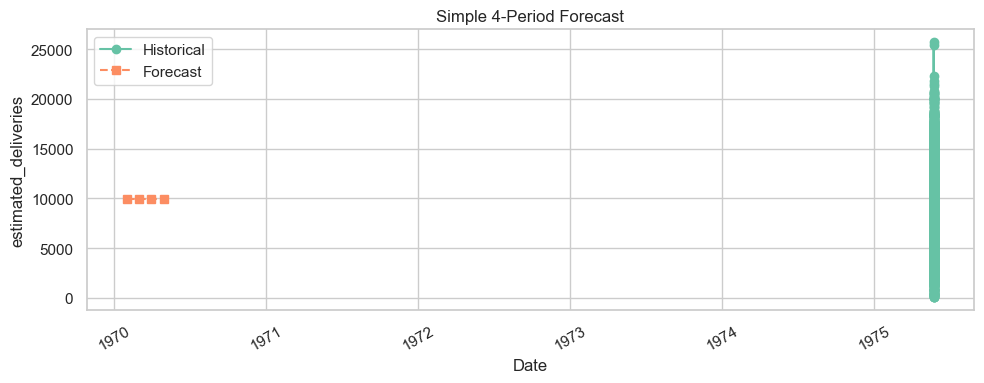

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(model_df[date_col], model_df[target_col], marker='o', label='Historical')
plt.plot(future[date_col], future['forecast'], marker='s', linestyle='--', label='Forecast')
plt.title('Simple 4-Period Forecast')
plt.xlabel('Date')
plt.ylabel(target_col)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()

## 8. Summary

- Cleaned and standardized the sales/price dataset.
- Explored trends, missing values, and numeric correlations.
- Added calendar, lag, rolling average, and percentage-change features.
- Compared baseline regression models using a chronological split.
- Tuned a Random Forest model with time-series cross-validation.
- Produced a simple four-period forecast suitable for a compact project submission.